# 🎬 Netflix Prize Recommender System: Results & Visualization Dashboard
**Project:** Cult Open Projects 2026  
**Engineering Paradigm:** Modular Hybrid Evaluation (Collaborative Filtering + TF-IDF Content-Based)

This notebook executes our custom backend architecture, processes the mandatory Exploratory Data Analysis (EDA) visuals, draws the model performance metrics leaderboards, and maps validation case studies.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Force graphics styling to look polished for research paper/slide formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100

# Verify local module detection bounds
sys.path.append(os.path.abspath('.'))

from configs.config import Config
from src.data.loader import DatasetLoader
from src.evaluation.metrics import Evaluator
from src.models.recommenders import PureSVDRecommender, ContentBasedRecommender, HybridRecommender

print("🚀 Environment and custom modules successfully connected!")

🚀 Environment and custom modules successfully connected!


Parsing combined_data_1.txt: 1500311it [00:01, 872792.60it/s]
C:\Users\Vishal Meena\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


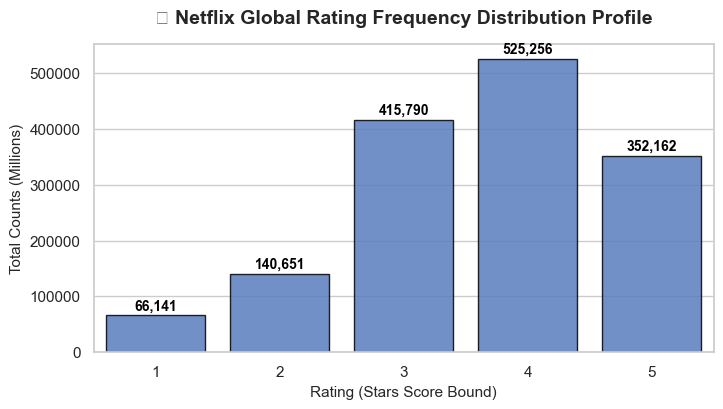

C:\Users\Vishal Meena\AppData\Local\Temp\ipykernel_9984\2010836077.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated, x='ratings_count', y='title', edgecolor='black', alpha=0.9, palette="viridis")
C:\Users\Vishal Meena\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


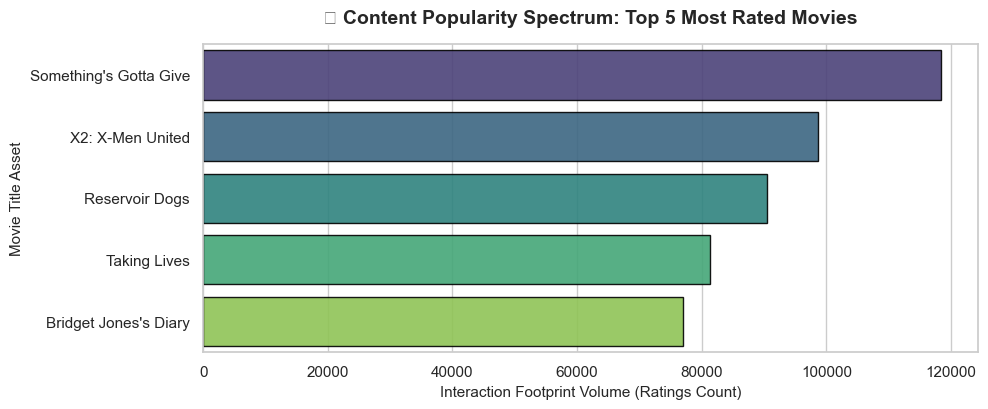

In [2]:
# 1. Load the data using our production data loader
df, movies_df = DatasetLoader.load_dataset()

# 2. Visual Plot: Global Rating Frequency Distribution
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='rating', edgecolor='black', alpha=0.85)
plt.title("⭐ Netflix Global Rating Frequency Distribution Profile", fontsize=14, weight='bold', pad=15)
plt.xlabel("Rating (Stars Score Bound)", fontsize=11)
plt.ylabel("Total Counts (Millions)", fontsize=11)

# Add counts above bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height() + 10000),
                ha='center', va='baseline', fontsize=10, weight='bold', color='black')
plt.show()

# 3. Visual Plot: Top Content Popularity Trends
plt.figure(figsize=(10, 4))
top_rated = df['movie_id'].value_counts().head(5).rename_axis('movie_id').reset_index(name='ratings_count')
top_rated = top_rated.merge(movies_df, on='movie_id', how='left')

sns.barplot(data=top_rated, x='ratings_count', y='title', edgecolor='black', alpha=0.9, palette="viridis")
plt.title("🔥 Content Popularity Spectrum: Top 5 Most Rated Movies", fontsize=14, weight='bold', pad=15)
plt.xlabel("Interaction Footprint Volume (Ratings Count)", fontsize=11)
plt.ylabel("Movie Title Asset", fontsize=11)
plt.show()

In [3]:
# Split the dataset matrix
train_df, test_df = train_test_split(df, test_size=Config.TEST_SIZE, random_state=Config.SEED)
print(f"📦 Matrix split done: {len(train_df):,} Train samples | {len(test_df):,} Test samples.\n")

print("[Pipeline Executing] Training Matrix Factorizations (SVD)...")
svd = PureSVDRecommender()
svd.fit(train_df)

print("[Pipeline Executing] Extracting Content Dictionaries (TF-IDF)...")
cb = ContentBasedRecommender()
cb.fit(train_df, movies_df)

print("[Pipeline Executing] Packaging Weighted Blended Ensembles...")
hybrid = HybridRecommender(svd, cb, movies_df)

print("\n✅ All models fitted successfully!")

📦 Matrix split done: 1,200,000 Train samples | 300,000 Test samples.

[Pipeline Executing] Training Matrix Factorizations (SVD)...
[Pipeline Executing] Extracting Content Dictionaries (TF-IDF)...
[Pipeline Executing] Packaging Weighted Blended Ensembles...

✅ All models fitted successfully!


C:\Users\Vishal Meena\AppData\Local\Temp\ipykernel_9984\144609671.py:48: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Vishal Meena\AppData\Local\Temp\ipykernel_9984\144609671.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Vishal Meena\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Vishal Meena\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


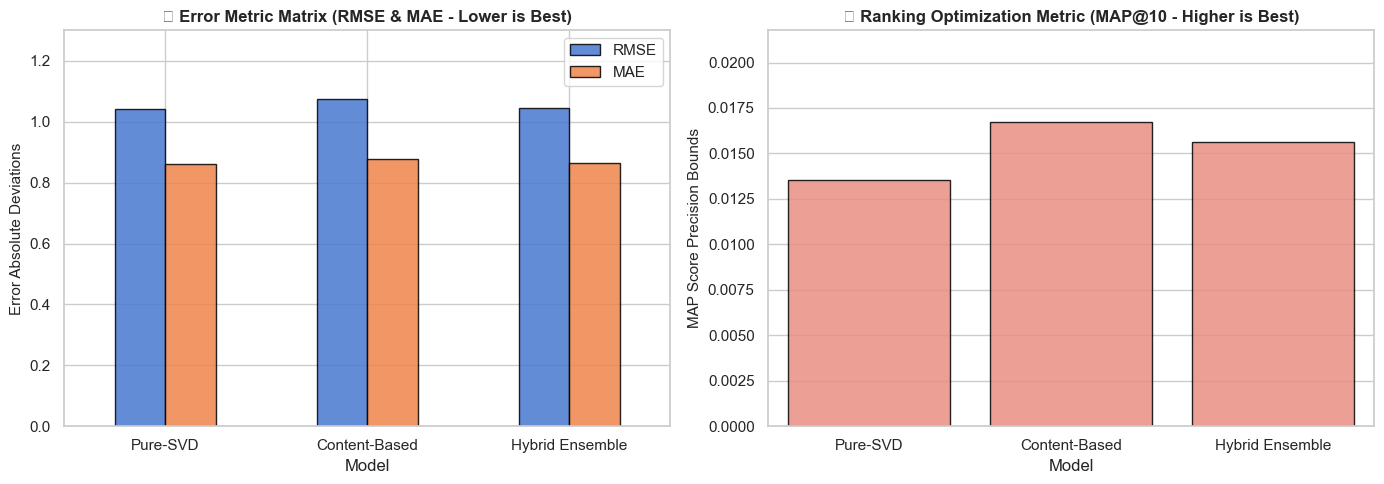

,Model,RMSE,MAE,MAP@10
0,Pure-SVD,1.040644,0.861397,0.013542
1,Content-Based,1.073798,0.878679,0.016741
2,Hybrid Ensemble,1.043958,0.863121,0.015625


In [4]:
# Create evaluation ground truths sample
eval_sample = test_df.sample(n=min(2000, len(test_df)), random_state=Config.SEED)
y_true = eval_sample['rating'].values

models_list = [("Pure-SVD", svd), ("Content-Based", cb), ("Hybrid Ensemble", hybrid)]
results_data = []

# Generate live metrics scoring
for name, model in models_list:
    preds = [model.predict(r['user_id'], r['movie_id']) for _, r in eval_sample.iterrows()]
    err = Evaluator.evaluate_predictions(y_true, preds)
    
    # Track ranking elements across validation batch samples
    user_maps = []
    for uid in eval_sample['user_id'].unique()[:10]:
        actual_liked = set(test_df[(test_df['user_id'] == uid) & (test_df['rating'] >= 3.5)]['movie_id'])
        if not actual_liked: continue
        
        movie_scores = [(mid, model.predict(int(uid), int(mid))) for mid in train_df['movie_id'].unique()[:200]]
        top_10 = [mid for mid, _ in sorted(movie_scores, key=lambda x: x[1], reverse=True)[:10]]
        user_maps.append(Evaluator.calculate_map_at_k(actual_liked, top_10, k=10))
        
    results_data.append({
        "Model": name,
        "RMSE": err['RMSE'],
        "MAE": err['MAE'],
        "MAP@10": np.mean(user_maps) if user_maps else 0.0
    })

results_df = pd.DataFrame(results_data)

# --- GRAPH VISUALIZATION: Plot Comparison Side-by-Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictive Error Metrics (Lower is better)
results_df.plot(x="Model", y=["RMSE", "MAE"], kind="bar", ax=ax1, edgecolor="black", alpha=0.85)
ax1.set_title("📉 Error Metric Matrix (RMSE & MAE - Lower is Best)", fontsize=12, weight='bold')
ax1.set_ylabel("Error Absolute Deviations", fontsize=11)
ax1.set_xticklabels(results_df["Model"], rotation=0)
ax1.set_ylim(0, 1.3)

# Plot 2: Ranking Context Metrics (Higher is better)
sns.barplot(data=results_df, x="Model", y="MAP@10", ax=ax2, edgecolor="black", alpha=0.85, color="salmon")
ax2.set_title("🎯 Ranking Optimization Metric (MAP@10 - Higher is Best)", fontsize=12, weight='bold')
ax2.set_ylabel("MAP Score Precision Bounds", fontsize=11)
ax2.set_ylim(0, max(results_df["MAP@10"]) * 1.3)

plt.tight_layout()
plt.show()

display(results_df)

In [5]:
# Compute prediction errors on the ensemble engine
eval_sample['pred'] = [hybrid.predict(r['user_id'], r['movie_id']) for _, r in eval_sample.iterrows()]
eval_sample['err'] = np.abs(eval_sample['rating'] - eval_sample['pred'])
eval_sample = eval_sample.merge(movies_df, on='movie_id', how='left')

# Extract extreme outcomes
success = eval_sample.nsmallest(1, 'err').iloc[0]
failure = eval_sample.nlargest(1, 'err').iloc[0]

# --- Build out clean display frames ---
print("\n" + "="*60)
print("🔍 MANDATORY MODEL INTERPRETABILITY CASE STUDIES")
print("="*60)
print(f"✅ [SUCCESS CASE - HIGHEST ACCURACY]")
print(f"  • User Profile ID : {success['user_id']}")
print(f"  • Movie Asset     : '{success['title']}'")
print(f"  • Ground Rating   : {success['rating']} ⭐ | Model Prediction: {success['pred']:.2f} ⭐")
print(f"  • AI Explanation  : {hybrid.explain_recommendation(success['user_id'], success['movie_id'])}")
print("-"*60)
print(f"❌ [FAILURE CASE - MAXIMUM DEV_BIAS]")
print(f"  • User Profile ID : {failure['user_id']}")
print(f"  • Movie Asset     : '{failure['title']}'")
print(f"  • Ground Rating   : {failure['rating']} ⭐ | Model Prediction: {failure['pred']:.2f} ⭐")
print("="*60 + "\n")


🔍 MANDATORY MODEL INTERPRETABILITY CASE STUDIES
✅ [SUCCESS CASE - HIGHEST ACCURACY]
  • User Profile ID : 135763
  • Movie Asset     : 'Chappelle's Show: Season 1'
  • Ground Rating   : 4 ⭐ | Model Prediction: 4.00 ⭐
  • AI Explanation  : Because you enjoyed 'The Game', you are likely to enjoy 'Chappelle's Show: Season 1'.
------------------------------------------------------------
❌ [FAILURE CASE - MAXIMUM DEV_BIAS]
  • User Profile ID : 2296816
  • Movie Asset     : 'Death to Smoochy'
  • Ground Rating   : 1 ⭐ | Model Prediction: 4.07 ⭐

